In [1]:
from src.data_loading import (
    TARGET_COL,
    ID_COL,
    load_data,
)
from src.models import make_lightGBM
from src.training import run_lgbm_cv
from src.evaluation import get_feature_importance, plot_feature_importance, get_error_cases, summarize_cv_results
from sklearn.metrics import roc_auc_score

application_train, application_test = load_data()
X = application_train[[c for c in application_train.columns if c not in [TARGET_COL, ID_COL]]]
y = application_train[TARGET_COL]


In [2]:
results = run_lgbm_cv(X, y)
summarize_cv_results(results, y)

mean_auc: 0.7622271491787286
std_auc: 0.0037081579366271176
oof_auc: 0.7622051691029313


feature_importance:    index               feature        fold_1        fold_2        fold_3  \
0     73       EXT_SOURCE_MEAN  57208.953634  56205.371040  56477.481404   
1    149     ORGANIZATION_TYPE  12090.861592  12107.031767  12573.755985   
2     27  CREDIT_ANNUITY_RATIO   6524.416519   5689.047140   7498.230207   
3    114    GOODS_CREDIT_RATIO   4943.470532   4414.156296   4633.901489   
4    151          PAYMENT_RATE   4304.370877   5161.820778   4066.956355   

         fold_4        fold_5  mean_importance  std_importance  
0  55733.538726  58950.870110     56915.242983     1257.181577  
1  12194.982890  12231.407159     12239.607879      195.841442  
2   7341.193708   5788.396186      6568.256752      843.415108  
3   4303.159258   4177.113008      4494.360117      301.996734  
4   3703.822151   5150.974957      4477.589024      655.545688  


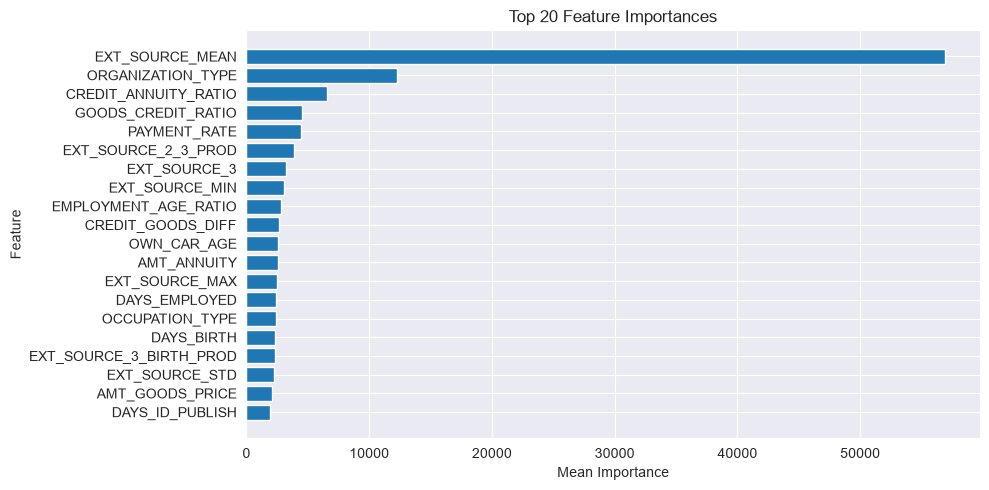

In [3]:
feature_importance = get_feature_importance(results["models"])
print(f"feature_importance: {feature_importance.head(5)}")
fig, axis = plot_feature_importance(feature_importance)

In [4]:
import pandas as pd
from IPython.display import display

false_positives, false_negatives = get_error_cases(X,y,results["oof_preds"])

error_case_summary = pd.DataFrame(
    {
        "group": ["false_positive", "false_negative"],
        "count": [len(false_positives), len(false_negatives)],
        "share_of_all_rows": [len(false_positives) / len(X), len(false_negatives) / len(X)],
        "mean_oof_pred": [false_positives["oof_pred"].mean(), false_negatives["oof_pred"].mean()],
        "median_oof_pred": [false_positives["oof_pred"].median(), false_negatives["oof_pred"].median()],
    }
)

display(error_case_summary)

def raw_column_from_feature(feature):
    if "__" in feature:
        feature = feature.split("__", 1)[1]
    if feature in X.columns:
        return feature
    for col in X.columns:
        if feature.startswith(f"{col}_"):
            return col
    return None

profile_columns = []
for feature in feature_importance["feature"]:
    raw_column = raw_column_from_feature(feature)
    if raw_column is not None and raw_column not in profile_columns:
        profile_columns.append(raw_column)
    if len(profile_columns) == 10:
        break

error_case_columns = ["y_true", "oof_pred", "y_pred"] + profile_columns

print("Highest-risk false positives")
display(false_positives[error_case_columns].head(10))

print("Lowest-risk false negatives")
display(false_negatives[error_case_columns].head(10))

error_profile = pd.DataFrame(
    {
        "overall_median": X[profile_columns].median(numeric_only=True),
        "false_positive_median": false_positives[profile_columns].median(numeric_only=True),
        "false_negative_median": false_negatives[profile_columns].median(numeric_only=True),
    }
)
error_profile["false_positive_minus_overall"] = (
    error_profile["false_positive_median"] - error_profile["overall_median"]
)
error_profile["false_negative_minus_overall"] = (
    error_profile["false_negative_median"] - error_profile["overall_median"]
)

display(error_profile.sort_values("false_negative_minus_overall", key=lambda col: col.abs(), ascending=False))

,group,count,share_of_all_rows,mean_oof_pred,median_oof_pred
0,false_positive,654,0.002127,0.564222,0.549933
1,false_negative,24113,0.078413,0.154045,0.123277


Highest-risk false positives


,y_true,oof_pred,y_pred,ORGANIZATION_TYPE,CREDIT_ANNUITY_RATIO,GOODS_CREDIT_RATIO,EXT_SOURCE_2,EXT_SOURCE_3,EMPLOYMENT_AGE_RATIO,OWN_CAR_AGE,AMT_ANNUITY,DAYS_EMPLOYED,OCCUPATION_TYPE
117350,0,0.828719,1,Industry: type 9,20.475025,0.703037,0.005267,0.142873,0.105423,64.0,31261.5,-1489.0,Laborers
116533,0,0.768681,1,Industry: type 10,12.468175,0.759430,0.009800,0.055711,0.057180,NaN,8554.5,-485.0,Laborers
155656,0,0.760986,1,XNA,21.452356,0.825627,0.088762,0.074461,NaN,NaN,25407.0,NaN,NaN
117772,0,0.751768,1,Self-employed,12.615455,0.816727,0.045806,NaN,0.201223,NaN,39307.5,-1744.0,Drivers
282543,0,0.748510,1,Business Entity Type 3,21.322715,0.703036,0.000954,0.065550,0.027125,16.0,21613.5,-231.0,Security staff
66660,0,0.745932,1,Trade: type 7,14.734251,0.759417,0.060446,0.025810,0.021334,0.0,40216.5,-236.0,Sales staff
122591,0,0.740445,1,Construction,20.441717,0.703036,0.042806,0.141992,0.190528,NaN,22545.0,-1931.0,Laborers
153864,0,0.735575,1,Construction,12.657497,0.904489,0.000320,NaN,0.104362,NaN,28300.5,-1146.0,Managers
117624,0,0.733692,1,Construction,12.593603,0.791139,0.132674,0.307737,0.045487,NaN,25744.5,-831.0,Laborers
141510,0,0.728296,1,Business Entity Type 2,16.488855,0.759417,0.333022,0.096948,0.097330,NaN,35937.0,-1287.0,Laborers


Lowest-risk false negatives


,y_true,oof_pred,y_pred,ORGANIZATION_TYPE,CREDIT_ANNUITY_RATIO,GOODS_CREDIT_RATIO,EXT_SOURCE_2,EXT_SOURCE_3,EMPLOYMENT_AGE_RATIO,OWN_CAR_AGE,AMT_ANNUITY,DAYS_EMPLOYED,OCCUPATION_TYPE
13998,1,0.002271,0,XNA,10.161580,0.883392,0.762684,0.785052,NaN,NaN,12532.5,NaN,NaN
113092,1,0.002311,0,Kindergarten,18.225663,0.954636,0.766670,0.452534,0.244750,9.0,103455.0,-3788.0,Core staff
296076,1,0.002324,0,XNA,30.261561,0.863262,0.772775,0.812823,NaN,16.0,27733.5,NaN,NaN
171712,1,0.003257,0,Business Entity Type 3,18.771240,0.945108,0.700609,0.750375,0.265272,1.0,60115.5,-6136.0,NaN
100284,1,0.003307,0,Business Entity Type 2,28.717694,0.863260,0.752758,0.735221,0.259999,NaN,72607.5,-3491.0,High skill tech staff
11857,1,0.003519,0,Military,25.151855,0.919862,0.675686,0.670652,0.231746,NaN,49014.0,-3850.0,High skill tech staff
287773,1,0.003608,0,Bank,10.532395,0.961908,0.786906,NaN,0.217193,4.0,88834.5,-3047.0,Managers
88236,1,0.004076,0,Security Ministries,14.904593,0.958258,0.707629,0.783832,0.299541,NaN,78768.0,-5283.0,Laborers
127110,1,0.004133,0,Medicine,28.714829,0.913209,0.669222,0.657784,0.024150,10.0,68643.0,-361.0,Accountants
37792,1,0.004136,0,Trade: type 7,10.068596,0.904489,0.770215,0.771362,0.152539,NaN,30636.0,-2773.0,Sales staff


,overall_median,false_positive_median,false_negative_median,false_positive_minus_overall,false_negative_minus_overall
DAYS_EMPLOYED,-1648.000000,-855.000000,-1252.000000,793.000000,396.000000
AMT_ANNUITY,24903.000000,26509.500000,25195.500000,1606.500000,292.500000
OWN_CAR_AGE,9.000000,13.000000,11.000000,4.000000,2.000000
EXT_SOURCE_3,0.535276,0.133852,0.389339,-0.401424,-0.145937
EXT_SOURCE_2,0.565961,0.100271,0.448999,-0.465690,-0.116963
EMPLOYMENT_AGE_RATIO,0.118733,0.065439,0.094969,-0.053294,-0.023764
GOODS_CREDIT_RATIO,0.893815,0.825625,0.873210,-0.068190,-0.020605
CREDIT_ANNUITY_RATIO,20.000000,19.531692,20.000000,-0.468308,0.000000
